In [1]:
import warnings
warnings.filterwarnings("ignore")

Imported libraries

In [2]:
# Data manipulation
import numpy as np           # for numerical operations
import pandas as pd          # for handling datasets (tables)

# Visualization
import seaborn as sns        # for making charts and plots
import matplotlib.pyplot as plt  # basic plotting library

from sklearn.model_selection import train_test_split  # split data into training and testing sets

# Modeling
## Pipeline
from sklearn.pipeline import Pipeline, make_pipeline   # Pipeline: run preprocessing and model in one step

## Model Selection / Hyperparameter tuning
from sklearn.model_selection import cross_val_score
# check model performance and tune parameters for better results

# Metrics to see how good the model is at predicting spam
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report

# Save / load model
import joblib  # save trained model to a file and load it later

Reading **Dataset**

In [3]:
df = pd.read_csv('emails.csv')
df

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
...,...,...
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0


In [4]:
# Shows the content of a chosen row
df.iloc[0, :]['text']

"Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , stylish statlonery and outstanding website  will make the task much easier .  we do not promise that havinq ordered a iogo your  company will automaticaily become a world ieader : it isguite ciear that  without good products , effective business organization and practicable aim it  will be hotat nowadays market ; but we do promise that your marketing efforts  will become much more effective . here is the list of clear  benefits : creativeness : hand - made , original logos , specially done  to reflect your distinctive company image . convenience : logo and stationery  are provided in all formats ; easy - to - use content management system letsyou  change your website content and even its structure . promptness : you  will see logo drafts within three business days . affordability : your  ma

In [5]:
# Checks dataset info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    5728 non-null   str  
 1   spam    5728 non-null   int64
dtypes: int64(1), str(1)
memory usage: 89.6 KB


Checking and handling missing values in dataset


In [6]:
print(df.isna().sum()) #Checks for missing value
df = df.dropna() #Deletes The row with Na value

text    0
spam    0
dtype: int64


Checking for dublicate


In [7]:
print(df.duplicated().sum()) # Count how many duplicate rows are in the dataset
df.drop_duplicates(inplace=True) # Removes all the duplicated rows
df.reset_index(inplace=True, drop=True) # Removes the Unneeded indexes after deleting the duplicated rows

33


In [8]:
# Checking again to make sure there's no duplicated rows
df.duplicated().sum()

np.int64(0)

#**Data** **Analysis**

Spam vs Non-Spam Count

In [9]:
counts = df['spam'].value_counts()  # Count how many emails belong to each class: 0 = not spam, 1 = spam

# Calculates what percent of emails are spam (1) vs not spam (0)
percentages = df['spam'].value_counts(normalize=True) * 100

print("Counts:\n", counts)
print("\nPercentages:\n", percentages)


Counts:
 spam
0    4327
1    1368
Name: count, dtype: int64

Percentages:
 spam
0    75.978929
1    24.021071
Name: proportion, dtype: float64


Spam vs Non-Spam Length

In [10]:
# Create a new column 'length' with the character count of each email
df['length'] = df['text'].apply(len)

# statistics of email length by class
length_stats = df.groupby('spam')['length'].describe()
print("\n Statistics of Email Length by Class:\n")
print(length_stats)


 Statistics of Email Length by Class:

       count         mean          std   min    25%     50%      75%      max
spam                                                                         
0     4327.0  1634.200139  1965.016383  13.0  577.5  1122.0  2037.50  43952.0
1     1368.0  1317.257310  2271.372893  18.0  401.5   693.5  1250.25  28432.0


#**Data** **Visualizations**

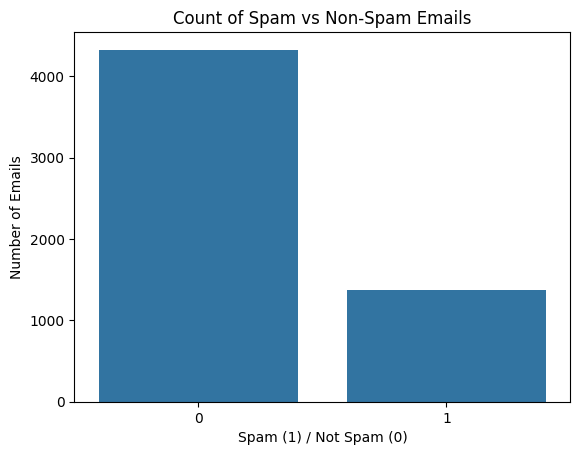

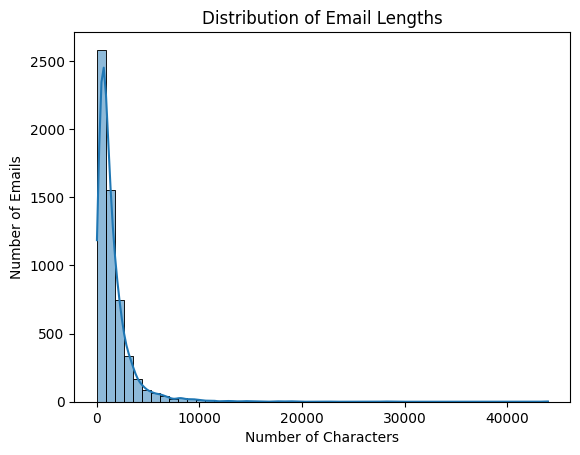

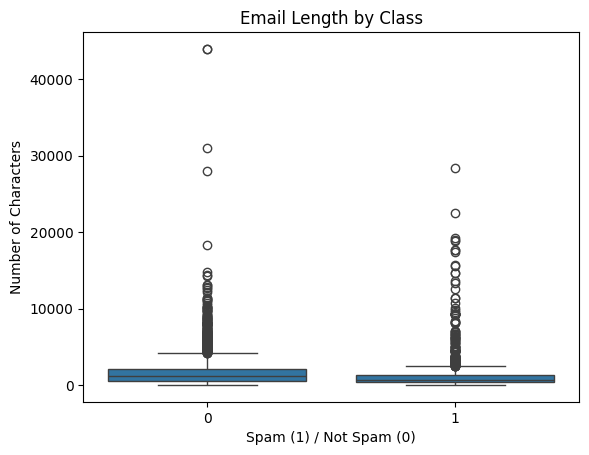

In [11]:
df['email_length'] = df['text'].str.len()
# 1) Bar chart: Count of spam vs non-spam
sns.countplot(x=df['spam'])
plt.title("Count of Spam vs Non-Spam Emails")
plt.xlabel("Spam (1) / Not Spam (0)")
plt.ylabel("Number of Emails")
plt.show()

#Histogram: Shows how email lengths are spread out
sns.histplot(df['email_length'], bins=50, kde=True)
plt.title("Distribution of Email Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Emails")
plt.show()

# 3) Boxplot: Email length by class
sns.boxplot(x='spam', y='email_length', data=df)
plt.title("Email Length by Class")
plt.xlabel("Spam (1) / Not Spam (0)")
plt.ylabel("Number of Characters")
plt.show()

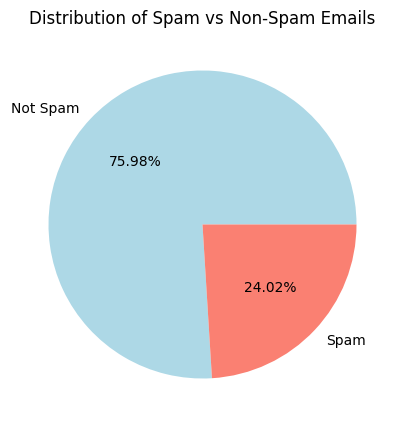

In [12]:
# Pie Chart: How many spam and non-spam emails
spread = df['spam'].value_counts()  # counts of 0 and 1
plt.rcParams['figure.figsize'] = (5,5)

# Make the pie chart
spread.plot(kind='pie', labels=['Not Spam', 'Spam'], autopct='%1.2f%%', colors=['lightblue', 'salmon'])
plt.title('Distribution of Spam vs Non-Spam Emails')

# Display the chart
plt.show()


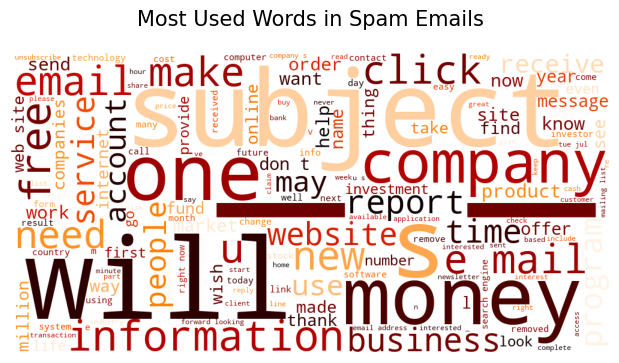

In [25]:
# --- WordCloud for Most Used Words in Spam Emails ---
from wordcloud import WordCloud, STOPWORDS

# check only spam emails
df_spam = df[df['spam'] == 1].copy()

# Make a big string of all words in spam emails
comment_words = ''

# Words to ignore (like 'the', 'and', 'is')
stopwords = set(STOPWORDS)

# Go through each spam email
for val in df_spam['text']:
    val = str(val)  # make sure it is text
    tokens = val.split()  # split into separate words
    tokens = [word.lower() for word in tokens]  # make all words lowercase
    comment_words += " ".join(tokens) + " "  # add words to big string

# Make the word cloud picture
wordcloud = WordCloud(
    width=1000, height=500,
    background_color='white',
    stopwords=stopwords,  # ignore common words
    min_font_size=10,
    max_words=1000,
    colormap='gist_heat_r'
).generate(comment_words)

# Show the word cloud
plt.figure(figsize=(6,6))
plt.title('Most Used Words in Spam Emails', fontsize=15, pad=20)
plt.imshow(wordcloud)  # show image
plt.axis("off")         # hide axes
plt.tight_layout(pad=0)
plt.show()


Prepare data for **training** and **testing**

In [14]:
# X is the email text (features), y is the label (spam or not spam)
X = df['text']
y = df['spam']

# Splits the emails and labels into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=42)

# Checks the number of samples in training and testing sets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4556,), (1139,), (4556,), (1139,))

Checking and handling for missing values in training data

In [15]:
# Check how many missing values are in each column of the training data
print(X_train.isna().sum())
X_train = X_train.dropna() #deletes the row of Na (missing) values

0


#**Model Training**

Transform email text into **machine-readable** numbers

In [16]:
# Imports TF-IDF vectorizer, which converts text into numbers that a model can understand.
from sklearn.feature_extraction.text import TfidfVectorizer

# Turns text into numbers, lowercase words, remove common words, and use single words only.
tfidf_vectorizer = TfidfVectorizer(encoding='utf-8', lowercase=True, analyzer='word', stop_words='english', ngram_range=(1, 1), norm='l2')

# Learn the words from training emails and convert them into numbers.
data = tfidf_vectorizer.fit_transform(X_train)

# Convert training numbers into a table with columns named after learned words
X_train_preprocessed = pd.DataFrame(data.todense(), columns=tfidf_vectorizer.get_feature_names_out())

# Convert test emails into numbers using the same words learned from training
data = tfidf_vectorizer.transform(X_test)

# Convert test numbers into a table with the same columns
X_test_preprocessed = pd.DataFrame(data.todense(), columns=tfidf_vectorizer.get_feature_names_out())

X_train_preprocessed #Shows the training data after turning it into numbers

,00,000,0000,000000,00000000,0000000000,000000000003619,000000000003991,000000000003997,000000000005168,...,zwzm,zxghlajf,zyban,zyc,zygoma,zymg,zzmacmac,zzn,zzncacst,zzzz
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4551,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4552,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4553,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4554,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
#Shows how many training samples and features the data has
X_train_preprocessed.shape

(4556, 33396)

In [18]:
from sklearn.linear_model import LogisticRegression

logestic_clf = LogisticRegression(C=1, class_weight='balanced', max_iter=100, random_state=42)
logestic_clf.fit(X_train_preprocessed, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`m

In [19]:
from sklearn.model_selection import cross_val_score, cross_val_predict

print(f"Train Accuracy: {logestic_clf.score(X_train_preprocessed, y_train)}")

val_scores = cross_val_score(logestic_clf, X_train_preprocessed, y_train, cv=5)
print(f"Valid Accuracy: {np.mean(val_scores)})")

Train Accuracy: 0.9940737489025461
Valid Accuracy: 0.9855145203843858)


Cross-Validation Metrics

In [20]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

y_valid_pred = cross_val_predict(logestic_clf, X_train_preprocessed, y_train, cv=3)
print(f"Valid Accuracy: {accuracy_score(y_train, y_valid_pred)})")
print(f"Valid Precision: {precision_score(y_train, y_valid_pred)}")
print(f"Valid recall: {recall_score(y_train, y_valid_pred)}")
print(f"Valid f1: {f1_score(y_train, y_valid_pred)}")

cm = confusion_matrix(y_train, y_valid_pred)
print(cm)

Valid Accuracy: 0.9846356453028973)
Valid Precision: 0.9429065743944637
Valid recall: 0.9963436928702011
Valid f1: 0.9688888888888889
[[3396   66]
 [   4 1090]]


Testing Model Predictions on the Test Set


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_test_pred = logestic_clf.predict(X_test_preprocessed)

print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred)}")
print(f"Test Precision: {precision_score(y_test, y_test_pred)}")
print(f"Test Recall: {recall_score(y_test, y_test_pred)}")
print(f"Test F1: {f1_score(y_test, y_test_pred)}")

cm = confusion_matrix(y_test, y_test_pred)
print(cm)

Test Accuracy: 0.990342405618964
Test Precision: 0.9614035087719298
Test Recall: 1.0
Test F1: 0.9803220035778175
[[854  11]
 [  0 274]]


Automatic Text Transformation and Spam Prediction

In [22]:
logestic_pipe = Pipeline([
    ('tf_idf', tfidf_vectorizer),
    ('model', logestic_clf),
])
logestic_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tf_idf', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [23]:
new_email = ["You won a free iPhone!"]
prediction = logestic_pipe.predict(new_email)
print(prediction)  # 0 = not spam, 1 = spam

[1]


Model Saving

In [24]:
import joblib
joblib.dump(logestic_pipe, 'Email_spam_detector.pkl')

['Email_spam_detector.pkl']